In [1]:
import pandas as pd 
import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from shapely.geometry import Point

In [2]:
listings = pd.read_csv(
    "../data/processed/listings_clean.csv"
)

neighborhoods = gpd.read_file(
    "../data/raw/neighbourhoods.geojson"
)

In [4]:
geometry = [
    Point(xy)
    for xy in zip(
        listings['longitude'],
        listings['latitude']
    )
]

gdf = gpd.GeoDataFrame(
    listings,
    geometry=geometry,
    crs='EPSG:4326'
)

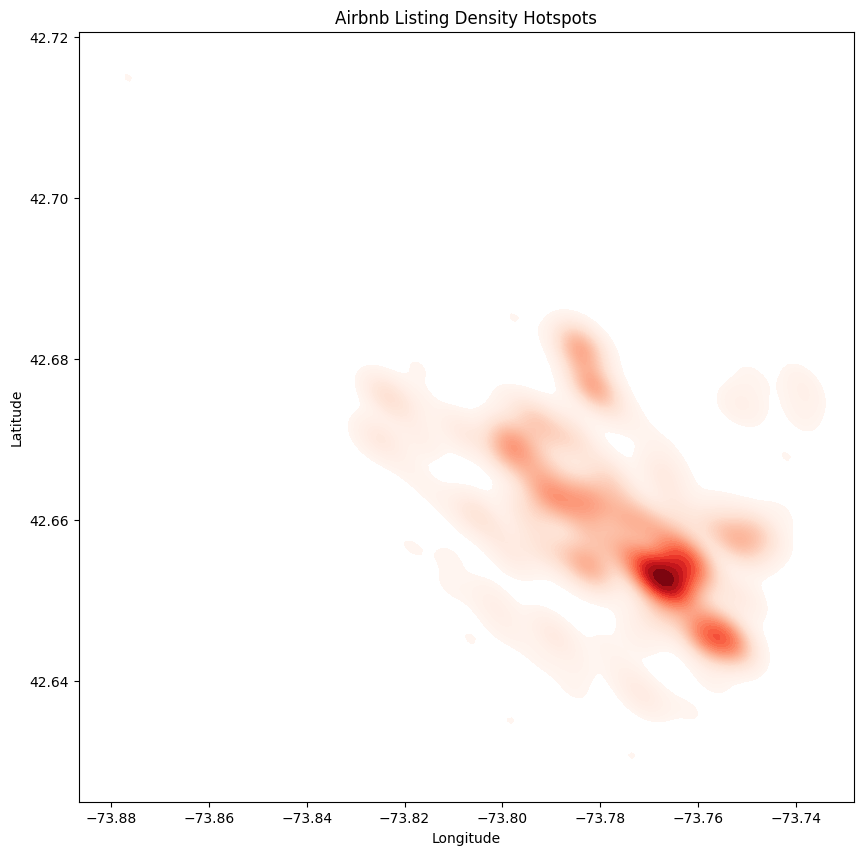

In [5]:
plt.figure(figsize=(10,10))

sns.kdeplot(
    x=gdf.geometry.x,
    y=gdf.geometry.y,
    fill=True,
    cmap='Reds',
    bw_adjust=0.5,
    levels=50,
    thresh=0.05
)

plt.title("Airbnb Listing Density Hotspots")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

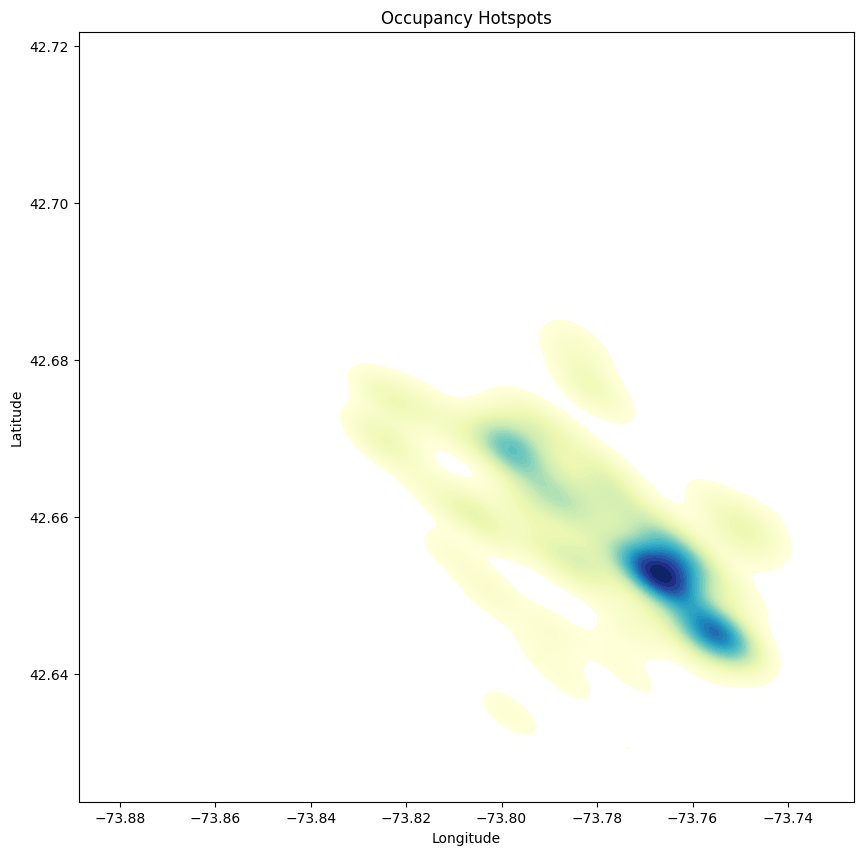

In [6]:
plt.figure(figsize=(10,10))

sns.kdeplot(
    x=gdf.geometry.x,
    y=gdf.geometry.y,
    weights=gdf['occupancy_rate'],
    fill=True,
    cmap='YlGnBu',
    bw_adjust=0.6,
    levels=50,
    thresh=0.05
)

plt.title("Occupancy Hotspots")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [7]:
commercial_hosts = gdf[
    gdf['calculated_host_listings_count'] >= 10
]

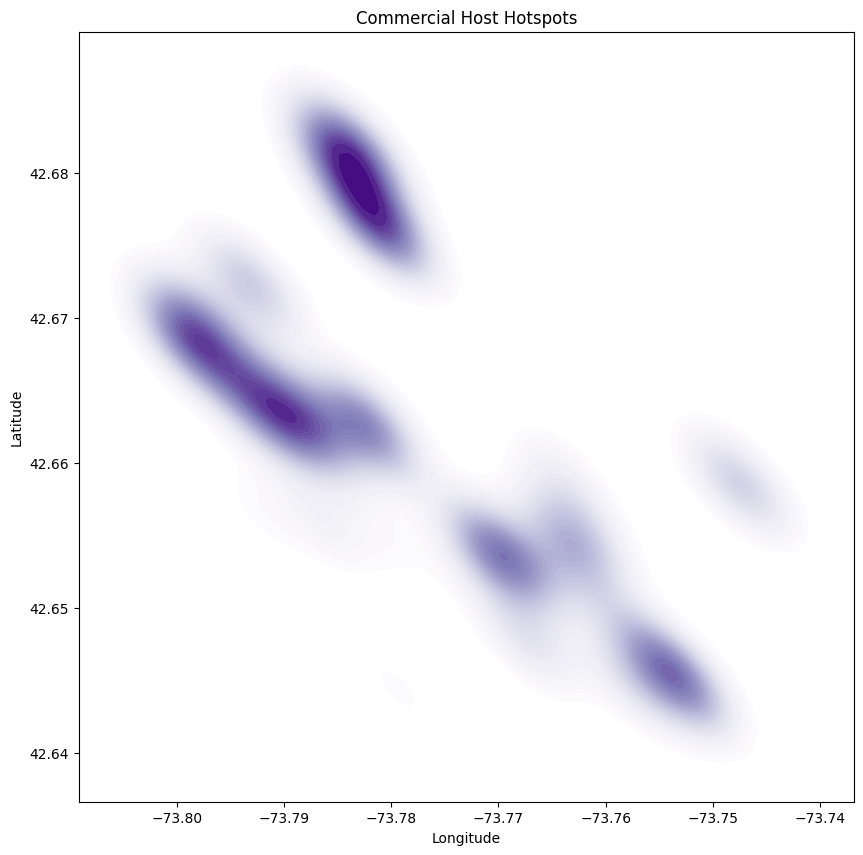

In [8]:
plt.figure(figsize=(10,10))

sns.kdeplot(
    x=commercial_hosts.geometry.x,
    y=commercial_hosts.geometry.y,
    fill=True,
    cmap='Purples',
    bw_adjust=0.5,
    levels=40,
    thresh=0.05
)

plt.title("Commercial Host Hotspots")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [9]:
coords = np.array([
    gdf.geometry.x,
    gdf.geometry.y
]).T


In [10]:
scaler = StandardScaler()

coords_scaled = scaler.fit_transform(coords)

In [11]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=8
)

clusters = dbscan.fit_predict(coords_scaled)

gdf['cluster'] = clusters

In [12]:
gdf['cluster'].value_counts()

cluster
 0    298
-1     78
 1     45
 2     32
Name: count, dtype: int64

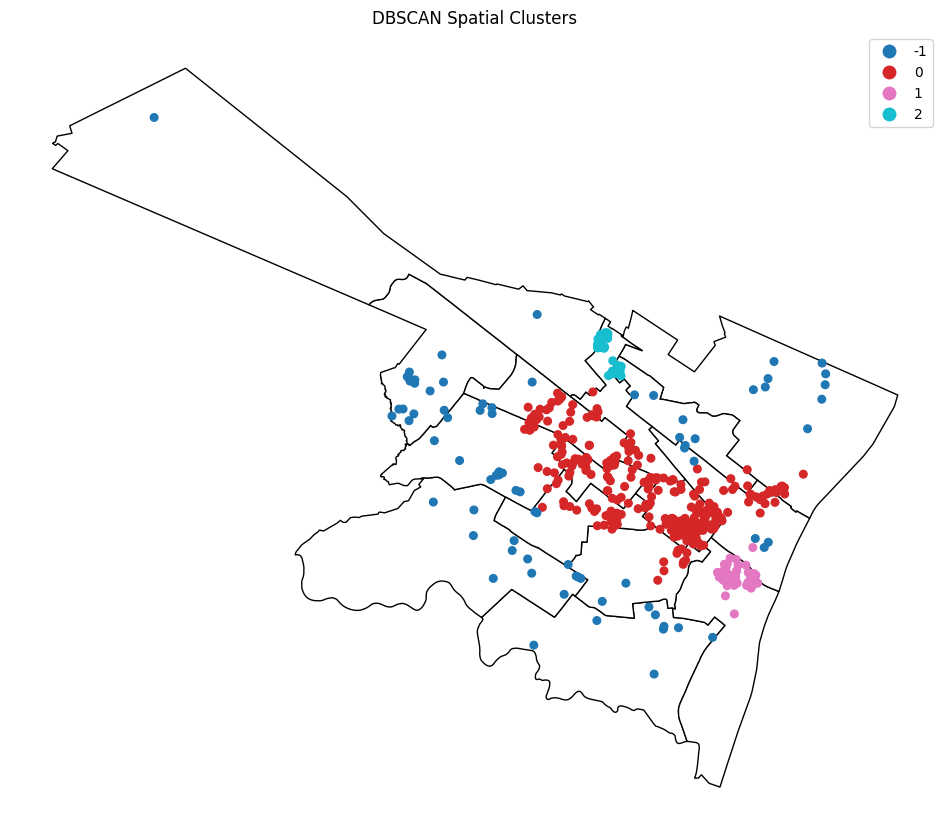

In [13]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

neighborhoods.plot(
    ax=ax,
    color='white',
    edgecolor='black'
)

gdf.plot(
    column='cluster',
    categorical=True,
    legend=True,
    markersize=30,
    ax=ax
)

plt.title("DBSCAN Spatial Clusters")

plt.axis('off')

plt.show()

In [14]:
cluster_summary = (
    gdf
    .groupby('cluster')
    .agg({
        'listing_id': 'count',
        'occupancy_rate': 'mean',
        'review_scores_rating': 'mean',
        'calculated_host_listings_count': 'mean'
    })
    .rename(columns={
        'listing_id': 'listing_count'
    })
)

cluster_summary

,listing_count,occupancy_rate,review_scores_rating,calculated_host_listings_count
cluster,,,,
-1,78,0.215806,4.821970,2.833333
0,298,0.214498,4.760543,6.936242
1,45,0.337473,4.738409,6.200000
2,32,0.089897,4.247778,28.250000
